In [1]:
import os
import re
import time
from collections import defaultdict
from operator import add
from typing import Annotated

import litellm
import pandas as pd
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

import agent_k.config.general as config_general
from agent_k.config.logger import logger
from agent_k.config.prompts_fast_n_slow import (
    QUESTION_TEMPLATE,
)
from agent_k.config.schemas import (
    TOTAL_MINERAL_RESERVE_CONTAINED_METAL_DESCRIPTION,
    TOTAL_MINERAL_RESERVE_TONNAGE_DESCRIPTION,
    TOTAL_MINERAL_RESOURCE_CONTAINED_METAL_DESCRIPTION,
    TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)
from agent_k.notebooks.agentic_rag_v5 import create_markdown_retriever
from agent_k.tools.python_code_interpreter import PythonExecTool

# Configs

In [2]:
MODEL = "gpt-4o-mini"
TEMPERATURE = 0.1

STEP_BACK_PROMPT = """Given a question that requires numerical reasoning, step back and think about the domain knowledge, math formula and relevant numerical value names required to solve the question. Generate a few examples that covers differnt corner cases without calculating the answer to help yourself understand the question better.

# Question
{question}
"""

EXTRACT_PROMPT = """Given a question that requires numerical reasoning and context from documents, extract the actual numerical values and their units that are required to solve the question based on your previous reasoning of the question.

All extracted numerical values must be present in the original context. If no relevant values are found, return "No relevant values found".

# Question
{question}

# Context
{context}
"""

PROGRAM_REASONER_USER_PROMPT = """You are a helper assistant that generate a python program to solve the question based on the given question and the context. You should follow the guidelines below:
1. The generated python program should be executable with correct syntax.
2. The final answer should be assigned to the variable `ans`.
3. The `ans` variable should be a float number.
4. Enclose the python code in ```python and ``` code block.

Based on the your previous intermediate reasoning, generate a python program to answer the given question now.

# Question
{question}"""

# Graph

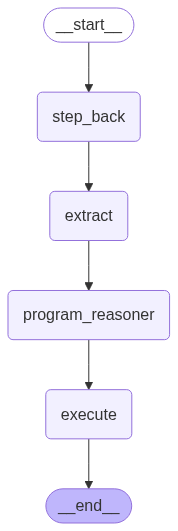

In [3]:
class GraphState(TypedDict):
    question: str
    context: str
    messages: Annotated[list[str], add]
    answer: float


def step_back(state: GraphState):
    logger.info("--STEP BACK PROMPTING--")

    response = litellm.completion(
        model=MODEL,
        temperature=TEMPERATURE,
        messages=[
            {
                "role": "user",
                "content": STEP_BACK_PROMPT.format(question=state["question"]),
            }
        ],
    )
    content = response["choices"][0]["message"]["content"]
    return {
        "messages": [
            {
                "role": "user",
                "content": STEP_BACK_PROMPT.format(question=state["question"]),
            },
            {"role": "assistant", "content": content},
        ]
    }


def extract(state: GraphState):
    logger.info("--EXTRACTING RELEVANT VALUES FROM THE CONTEXT--")

    response = litellm.completion(
        model=MODEL,
        temperature=TEMPERATURE,
        messages=[
            *state["messages"],
            {
                "role": "user",
                "content": EXTRACT_PROMPT.format(
                    question=state["question"], context=state["context"]
                ),
            },
        ],
    )
    content = response["choices"][0]["message"]["content"]
    return {
        "messages": [
            {
                "role": "user",
                "content": EXTRACT_PROMPT.format(
                    question=state["question"], context=state["context"]
                ),
            },
            {"role": "assistant", "content": content},
        ]
    }


def program_reasoner(state: GraphState):
    logger.info("--GENERATING PYTHON PROGRAM TO ANSWER THE QUESTION--")

    response = litellm.completion(
        model=MODEL,
        temperature=TEMPERATURE,
        messages=[
            *state["messages"],
            {
                "role": "user",
                "content": PROGRAM_REASONER_USER_PROMPT.format(
                    question=state["question"]
                ),
            },
        ],
    )
    content = response["choices"][0]["message"]["content"]
    return {
        "messages": [
            {"role": "user", "content": PROGRAM_REASONER_USER_PROMPT},
            {"role": "assistant", "content": content},
        ]
    }


def execute(state: GraphState):
    logger.info("--EXECUTING THE PYTHON PROGRAM--")

    msg_w_code = state["messages"][-1]["content"]
    output = PythonExecTool().run_code_block(msg_w_code)

    logger.info("--EXECUTION OUTPUT--")
    logger.info(output)

    return {"answer": output}


graph_builder = StateGraph(GraphState)
graph_builder.add_node("step_back", step_back)
graph_builder.add_node("extract", extract)
graph_builder.add_node("program_reasoner", program_reasoner)
graph_builder.add_node("execute", execute)

graph_builder.add_edge(START, "step_back")
graph_builder.add_edge("step_back", "extract")
# graph_builder.add_edge(START, "extract")
graph_builder.add_edge("extract", "program_reasoner")
graph_builder.add_edge("program_reasoner", "execute")
graph_builder.add_edge("execute", END)

display(
    Image(
        graph_builder.compile()
        .get_graph()
        .draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [4]:
if __name__ == "__main__":
    question = QUESTION_TEMPLATE.format(
        field="total_mineral_resource_tonnage",
        dtype="float",
        default=0,
        description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
    )

    retriever = create_markdown_retriever(
        "paper/data/processed/43-101-refined/0200a1c6d2cfafeb485d815d95966961d4c119e8662b8babec74e05b59ba4759d2.md",
        collection_name="rag-chroma",
    )

    documents = retriever.invoke(question)

    graph_inputs = {
        "question": question,
        "context": documents,
    }

    # Compile graph and invoke
    graph = graph_builder.compile()
    result = graph.invoke(graph_inputs, config={"recursion_limit": 12})

    for message in result["messages"]:
        logger.debug(message)

    # Final generation
    logger.info("---FINAL GENERATION---")
    logger.info(result["answer"])

2025-07-02 18:36:04.116 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:117 - Number of tokens: 49301
2025-07-02 18:36:04.117 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:118 - Number of splits: 52
2025-07-02 18:36:04.118 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:119 - Average tokens per split: 948
2025-07-02 18:36:04.346 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:132 - Hashed collection name: rag-chroma_shard_1
2025-07-02 18:36:07.091 | INFO     | __main__:step_back:9 - --STEP BACK PROMPTING--
2025-07-02 18:36:18.327 | INFO     | __main__:extract:34 - --EXTRACTING RELEVANT VALUES FROM THE CONTEXT--
2025-07-02 18:36:20.878 | INFO     | __main__:program_reasoner:64 - --GENERATING PYTHON PROGRAM TO ANSWER THE QUESTION--
2025-07-02 18:36:23.362 | INFO     | __main__:execute:84 - --EXECUTING THE PYTHON PROGRAM--
2025-07-02 18:36:23.623 | INFO     | __main__:execute:89 - --EXECUTION

# Run Experiments

In [4]:
complex_properties = [
    (
        "total_mineral_resource_tonnage",
        "float",
        0,
        TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
    ),
    (
        "total_mineral_reserve_tonnage",
        "float",
        0,
        TOTAL_MINERAL_RESERVE_TONNAGE_DESCRIPTION,
    ),
    (
        "total_mineral_resource_contained_metal",
        "float",
        0,
        TOTAL_MINERAL_RESOURCE_CONTAINED_METAL_DESCRIPTION,
    ),
    (
        "total_mineral_reserve_contained_metal",
        "float",
        0,
        TOTAL_MINERAL_RESERVE_CONTAINED_METAL_DESCRIPTION,
    ),
]


def run_experiment(gt_path: str, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    df_gt = pd.read_csv(gt_path)

    rows = []
    tokens = defaultdict(int)
    start_time = time.time()
    for index, row in df_gt.iterrows():
        # if index > 0:
        #     break

        logger.info(f"Processing row {index + 1} of {len(df_gt)}")
        id = row["id"]
        cdr_record_id = row["cdr_record_id"]
        commodity_observed_name = row["commodity_observed_name"]
        row_template = {
            "id": id,
            "cdr_record_id": cdr_record_id,
            "commodity_observed_name": commodity_observed_name,
            "total_mineral_resource_tonnage": -1,
            "total_mineral_reserve_tonnage": -1,
            "total_mineral_resource_contained_metal": -1,
            "total_mineral_reserve_contained_metal": -1,
        }

        retriever = create_markdown_retriever(
            f"paper/data/processed/43-101-refined/{cdr_record_id}.md",
            collection_name="rag-chroma",
        )
        for (
            property_name,
            property_dtype,
            property_default,
            property_description,
        ) in complex_properties:
            question = QUESTION_TEMPLATE.format(
                field=property_name,
                dtype=property_dtype,
                default=property_default,
                description=property_description.replace(
                    "<main_commodity>", commodity_observed_name
                ),
            )
            documents = retriever.invoke(question)
            graph_inputs = {
                "question": question,
                "context": documents,
            }
            # Compile graph and invoke
            graph = graph_builder.compile()
            result = graph.invoke(graph_inputs, config={"recursion_limit": 12})

            # Parse the integer or float number from the answer using regex
            match = re.search(r"(\d+\.\d+)", result["answer"])
            if match is None:
                logger.error(f"No float number found in the answer: {result['answer']}")
                row_template[property_name] = -1
            else:
                logger.info(
                    f"Found float number in the answer: {match.group(1)}. Convert to Mt."
                )
                row_template[property_name] = float(match.group(1)) / 1e6

        rows.append(row_template)
        df_pred = pd.DataFrame(rows)

        # Save results to CSV incrementally after every report extraction
        timestamp = config_general.get_curr_ts()
        df_pred.to_csv(f"{output_dir}/{timestamp}_ere_extraction.csv", index=False)
        logger.info(f"Write the CSV file to experiment results directory {output_dir}.")


if __name__ == "__main__":
    output_dir = "paper/data/experiments/250629_extract_reason_exec"
    gt_path = "paper/data/processed/ground_truth/inferlink_ground_truth.csv"
    run_experiment(
        gt_path=gt_path,
        output_dir=output_dir,
    )

2025-07-02 18:46:09.925 | INFO     | __main__:run_experiment:40 - Processing row 1 of 50
2025-07-02 18:46:09.982 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:117 - Number of tokens: 49301
2025-07-02 18:46:09.983 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:118 - Number of splits: 52
2025-07-02 18:46:09.984 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:119 - Average tokens per split: 948
2025-07-02 18:46:10.140 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:132 - Hashed collection name: rag-chroma_shard_1
2025-07-02 18:46:11.891 | INFO     | __main__:step_back:9 - --STEP BACK PROMPTING--
2025-07-02 18:46:27.314 | INFO     | __main__:extract:34 - --EXTRACTING RELEVANT VALUES FROM THE CONTEXT--
2025-07-02 18:46:29.915 | INFO     | __main__:program_reasoner:64 - --GENERATING PYTHON PROGRAM TO ANSWER THE QUESTION--
2025-07-02 18:46:33.165 | INFO     | __main__:execute:84 - --EXECUTING TH

# Schema Map Reduce

In [6]:
from typing import Any, Literal, TypedDict

from langgraph.types import Send


class State(TypedDict):
    md_path: str
    json_schema: dict
    retriever: Any


class ComplexEntityState(TypedDict):
    entity_name: str
    description: str
    default_value: Any
    dtype: Literal["string", "number", "boolean", "array", "object"]
    retriever: Any


def map_extraction_route(state: State):
    next_nodes = []

    for entity_name, entity_schema in state["json_schema"]["properties"].items():
        next_nodes.append(
            Send(
                "map_extract_reason_exec",
                {
                    "entity_name": entity_name,
                    "description": entity_schema.get("description"),
                    "default_value": entity_schema.get("default"),
                    "dtype": entity_schema.get("type"),
                    "retriever": state["retriever"],
                },
            )
        )

    return next_nodes